<a href="https://colab.research.google.com/github/elemnurguner/data-ai-projects/blob/main/Silah_Tehlikeli_Obje_Tespiti_Projesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()    # gun_detect.pt yükle


Saving gun_detect.pt to gun_detect.pt


In [ ]:
!pip install ultralytics opencv-python matplotlib

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import Video


In [ ]:
files.upload()   # img.jpg


In [ ]:
files.upload()   # video.mp4


Resim  işleme

Tespit edilen nesne sayısı: 1


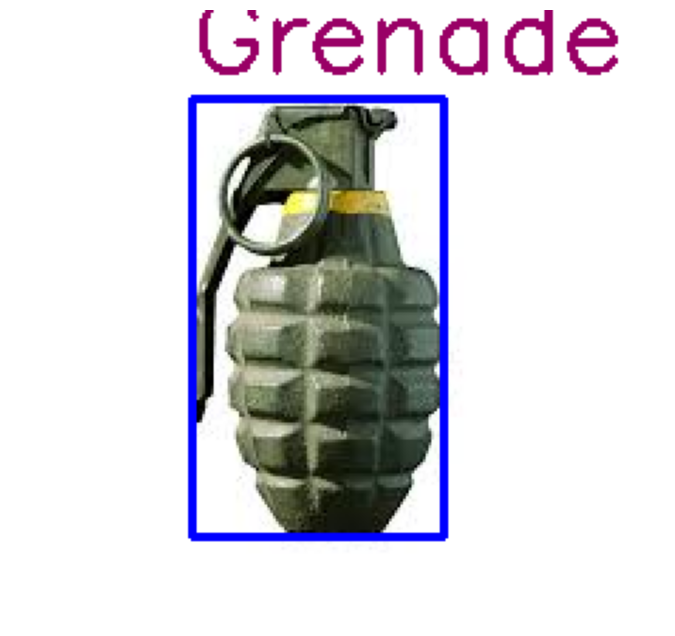

In [17]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("gun_detect.pt")  # Model dosyanın adını buraya

def detect_on_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("⚠️ Görsel okunamadı!")
        return

    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(rgb_img, verbose=False)

    print(f"Tespit edilen nesne sayısı: {len(results[0].boxes)}")

    labels = results[0].names
    for i in range(len(results[0].boxes)):
        x1, y1, x2, y2 = results[0].boxes.xyxy[i]
        score = results[0].boxes.conf[i]
        label = results[0].boxes.cls[i]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        score = float(score)
        label = int(label)
        name = labels[label]

        if score < 0.5:
            continue

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        text = f"{name} {score:.2f}"
        cv2.putText(img, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (102, 0, 153), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Örnek kullanım
detect_on_image('bomba.jpg')


vidyo işleme

In [18]:
def detect_on_video(video_path, output_path='output.mp4'):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("⚠️ Video açılamadı!")
        return

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 20.0
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    font = cv2.FONT_HERSHEY_SIMPLEX

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model(rgb_frame, verbose=False)
        labels = results[0].names

        for i in range(len(results[0].boxes)):
            x1, y1, x2, y2 = results[0].boxes.xyxy[i]
            score = results[0].boxes.conf[i]
            label = results[0].boxes.cls[i]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            score = float(score)
            label = int(label)
            name = labels[label]

            if score < 0.5:
                continue

            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
            text = f"{name} {score:.2f}"
            cv2.putText(frame, text, (x1, y1 - 10), font, 1.2, (102, 0, 153), 2)

        out.write(frame)
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"✅ {frame_count} kare işlendi...")

    cap.release()
    out.release()
    print(f"✅ İşlenmiş video kaydedildi: {output_path}")


# Silah Tespiti YOLOv8 Projesi

Bu proje, YOLOv8 modeli kullanarak **bıçak, el bombası, tabanca, tüfek gibi silahları** görüntü ve videolarda tespit etmeyi sağlar.

---

## Özellikler

- YOLOv8 tabanlı silah tespiti
- Görsel (resim) veya video dosyası üzerinden tespit
- OpenCV ile tespit edilen nesnelerin kutulanması ve etiketlenmesi
- Google Colab uyumlu (dosya yükleme ve görüntüleme)

---

## Gereksinimler

- Python 3.7+
- ultralytics
- opencv-python
- matplotlib
- Google Colab (opsiyonel, ama önerilir)

---

## Kurulum

```bash
pip install ultralytics opencv-python matplotlib
